In [1]:
import numpy as np
import xtrack as xt
import xobjects as xo
import xpart as xp
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy import constants 
import xfields as xf


In [2]:
#line = xt.Line.from_json('sps.json')
import json

with open('sps.json', 'r') as f:
    line = xt.Line.from_dict(json.load(f))  


particle_ref=line.particle_ref

line.build_tracker()
twiss=line.twiss()

clight=constants.speed_of_light
circumference = line.get_length()

Xcoll not installed


Loading line from dict:   0%|          | 0/38786 [00:00<?, ?it/s]

Done loading line from dict.           
Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.


In [3]:
from ion_properties import lead,calcium,xenon


In [4]:
dp_list=[]
for ion in [calcium]:

    # Ion properties:
    q0 = ion.q0
    mass0 = ion.mass0

    gamma = ion.gamma_cooling
    beta= ion.beta_rel
    p0c = mass0*gamma*beta #eV/c

    bunch_intensity = ion.bunch_intensity

    particle_ref = xp.Particles(p0c=p0c, mass0=mass0, q0=q0, gamma0=gamma)

    line.particle_ref=particle_ref

    nemitt = 1.5e-6 # m*rad (normalized emittance)
    sigma_z = 0.063 # m
    sigma_z=ion.bunch_length
    # sigma_z=9.5*1e-2

    emittance=nemitt/(beta*gamma)

    num_particles=int(1e3)

    particles = xp.generate_matched_gaussian_bunch(
            num_particles=num_particles,
            total_intensity_particles=bunch_intensity,
            nemitt_x=nemitt, nemitt_y=nemitt, sigma_z=sigma_z,
            particle_ref=particle_ref,
            line=line,        
            )
    
    particles._init_random_number_generator()

    particles0=particles.copy()
    # sigma_dp=2e-4  
    sigma_dp=np.std(particles.delta)

    print(sigma_dp*1e4)

    dp_list.append(sigma_dp)

*** Maximum RMS bunch length 0.23411645756327412m.


/home/pkruyt/miniforge3/envs/xsuite_coolers/lib/python3.13/site-packages/scipy/integrate/_quadpack_py.py:1260: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  quad_r = quad(f, low, high, args=args, full_output=self.full_output,


... distance to target bunch length: -9.3234e-02
... distance to target bunch length: 1.3265e-01
... distance to target bunch length: 9.6426e-02
... distance to target bunch length: 5.5382e-03
... distance to target bunch length: -6.2242e-04
... distance to target bunch length: -5.3543e-06
... distance to target bunch length: 8.6936e-11
... distance to target bunch length: -5.2310e-07
--> Bunch length: 0.09500000008693617
--> Emittance: 0.3669203616089407
Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.
1.9926403451285795


In [5]:
# from scipy.stats import norm

# class ThresholdInteractionProcess:
#     '''
#     Removes particles where delta is greater than the given threshold.
#     '''
#     def __init__(self, threshold):
#         self.threshold = threshold

#     def interact(self, particles):
#         n_part = particles._num_active_particles

#         # Kill particles where delta > threshold
#         data=particles.delta[:n_part]
#         p10, p90 = np.percentile(data, [10, 90])

#         # Select only values within the central 80% range
#         filtered_data = data[(data >= p10) & (data <= p90)]

#         # Fit a Gaussian to the filtered data
#         mu, sigma = norm.fit(filtered_data)
#         mask_kill = np.abs(data) > 10*sigma



#         particles.state[:n_part][mask_kill] = -42  # Mark as lost

#         return None  # No secondary particles

# # Example usage
# interaction_process = ThresholdInteractionProcess(threshold=4e-4)
# collimator = xt.BeamInteraction(length=0.0, interaction_process=interaction_process)


In [ ]:
for ion in [calcium]:
    context = xo.ContextCpu(omp_num_threads=4)
    # Ion properties:
    q0 = ion.q0
    mass0 = ion.mass0

    gamma = ion.gamma_cooling
    beta= ion.beta_rel
    p0c = mass0*gamma*beta #eV/c

    bunch_intensity = ion.bunch_intensity

    particle_ref = xp.Particles(p0c=p0c, mass0=mass0, q0=q0, gamma0=gamma)

    line.particle_ref=particle_ref

    nemitt = 1.5e-6 # m*rad (normalized emittance)
    sigma_z = 0.063 # m
    sigma_z = ion.bunch_length


    emittance=nemitt/(beta*gamma)

    #num_particles=int(1e3)

#     particles = xp.generate_matched_gaussian_bunch(
#             num_particles=num_particles,
#             total_intensity_particles=bunch_intensity,
#             nemitt_x=nemitt, nemitt_y=nemitt, sigma_z=sigma_z,
#             particle_ref=particle_ref,
#             line=line,        
#             )

    with open('particles.json', 'r') as fid:
        particles= xp.Particles.from_dict(json.load(fid), _context=context)
    num_particles=len(particles.x)
    particles._init_random_number_generator()

   
    # sigma_dp=2e-4  
    sigma_dp=np.std(particles.delta)

    ##################
    # Laser Cooler #
    ##################

    #laser-ion beam collision angle
    theta_l = 2.6*np.pi/180 # rad
    #theta_l = ion.theta_l
    nx = 0; ny = -np.sin(theta_l); nz = -np.cos(theta_l)

    # Ion excitation energy:
    ion_excited_lifetime=ion.excited_lifetime
    hw0 = ion.hw0 # eV
    hc=constants.hbar*clight/constants.e # eV*m (ħc)
    lambda_0 = 2*np.pi*hc/hw0 # m -- ion excitation wavelength

    lambda_l = lambda_0*gamma*(1 + beta*np.cos(theta_l)) # m -- laser wavelength

    # Shift laser wavelength for fast longitudinal cooling:
    #lambda_l = lambda_l*(1+1*sigma_dp) # m

    lambda_l = ion.lambda_l

    laser_frequency = clight/lambda_l # Hz
    sigma_w = 2*np.pi*laser_frequency*sigma_dp
    #sigma_w = 2*np.pi*laser_frequency*sigma_dp/2 # for fast longitudinal cooling

    sigma_t = 1/sigma_w # sec -- Fourier-limited laser pulse
    print('Laser pulse duration sigma_t = %.2f ps' % (sigma_t/1e-12))
    print('Laser wavelength = %.2f nm' % (lambda_l/1e-9))

    laser_waist_radius = 1.3e-3 #m
    laser_energy = 5e-3
    #laser_energy = ion.pulse_energy
    laser_x = ion.laser_x

    GF_IP = xt.PulsedLaser(
                    laser_x=laser_x,
                    laser_y=0,
                    laser_z=0,
                    
                    laser_direction_nx = 0,
                    laser_direction_ny = ny,
                    laser_direction_nz = nz,
                    laser_energy         = laser_energy, # J
                    laser_duration_sigma = sigma_t, # sec
                    laser_wavelength = lambda_l, # m
                    laser_waist_radius = laser_waist_radius, # m
                    laser_waist_shift = 0, # m
                    ion_excitation_energy = hw0, # eV
                    ion_excited_lifetime  = ion_excited_lifetime, # sec                   
                    )

    # simulation parameters: simulate 10 s of cooling, and take data once every 100 ms
    max_time_s = 1
    int_time_s = 0.01
    T_per_turn = circumference/(clight*beta)
    num_turns = int(max_time_s/T_per_turn)
    save_interval = int(int_time_s/T_per_turn)

    # create a monitor object, to reduce holded data
    monitor = xt.ParticlesMonitor(start_at_turn=0, stop_at_turn=1,
                                n_repetitions=int(num_turns/save_interval),
                                repetition_period=save_interval,
                                num_particles=num_particles)
    
    arg_min =  np.argmin(np.abs(twiss.dx))    

    ibs_kick = xf.IBSKineticKick(num_slices=50)
    line.configure_intrabeam_scattering(
    element=ibs_kick, name="ibskick", index=arg_min, update_every=25)


    line.discard_tracker()
    IP_index=16675   
    line.insert_element('monitor', element=monitor, index=IP_index)
    line.insert_element('GF_IP', element=GF_IP, index=IP_index) #this way monitor comes after the laser
    #line.insert_element('collimator', element=collimator, index=IP_index) #this way monitor comes after the laser

    # at interaction points: #from https://anaconda.org/petrenko/li_like_ca_in_sps/notebook
    beta_x  =  twiss.betx[IP_index]
    beta_y  =  twiss.bety[IP_index]
    alpha_x =  twiss.alfx[IP_index]
    alpha_y =  twiss.alfy[IP_index]

    gamma_x=twiss.gamx[IP_index]
    gamma_y=twiss.gamy[IP_index]

    Dx  =  twiss.dx[IP_index]
    Dpx =  twiss.dpx[IP_index]

    Dy  =  twiss.dy[IP_index]
    Dpy =  twiss.dpy[IP_index]

    
    line.build_tracker(_context=context)
    #line.optimize_for_tracking()   

    line.track(particles, num_turns=num_turns,
                turn_by_turn_monitor=False,with_progress=True)

    # extract relevant values
    x = monitor.x[:,:,0]
    px = monitor.px[:,:,0]
    y = monitor.y[:,:,0]
    py = monitor.py[:,:,0]
    delta = monitor.delta[:,:,0]
    zeta = monitor.zeta[:,:,0]
    state = monitor.state[:,:,0]
    time = monitor.at_turn[:, 0, 0] * T_per_turn

    action_x = (gamma_x*(x-Dx*delta)**2 + 2*alpha_x*(x-Dx*delta)*(px-Dpx*delta)+ beta_x*(px-Dpx*delta)**2)
    action_y = (gamma_y*(y-Dy*delta)**2 + 2*alpha_y*(y-Dy*delta)*(py-Dpy*delta)+ beta_y*(py-Dpy*delta)**2)

    emittance_x_twiss=np.mean(action_x,axis=1)*beta*gamma/2

    np.savez(f'results/IBS_custom/{ion.name}_output.npz', x=x, px=px, y=y, py=py, zeta=zeta, delta=delta,
            action_x=action_x,action_y=action_y,emittance_x=emittance_x_twiss,
            state=state, time=time,s_per_turn=T_per_turn)


Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.
Laser pulse duration sigma_t = 3.18 ps
Laser wavelength = 768.00 nm
Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.
The line has collective elements.
In the twiss computation collective elements are replaced by drifts
Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.
Compiling ContextCpu kernels...


3f2f8b1eff0d4d0e9a3886f11953999a.c:10541: warning: "POW3" redefined
10541 | #define POW3(X) ((X)*(X))
      | 
3f2f8b1eff0d4d0e9a3886f11953999a.c:5133: note: this is the location of the previous definition
 5133 | #define POW3(X) ((X)*(X)*(X))
      | 


Done compiling ContextCpu kernels.


Tracking:   0%|          | 0/43400 [00:00<?, ?it/s]

Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.


In [7]:
arg_min =  np.argmin(np.abs(twiss.dx))
twiss.dx[arg_min]

np.float64(-0.00015602589091330308)

In [8]:
 # extract relevant values
x = monitor.x[:,:,0]
px = monitor.px[:,:,0]
y = monitor.y[:,:,0]
py = monitor.py[:,:,0]
delta = monitor.delta[:,:,0]
zeta = monitor.zeta[:,:,0]
state = monitor.state[:,:,0]
time = monitor.at_turn[:, 0, 0] * T_per_turn

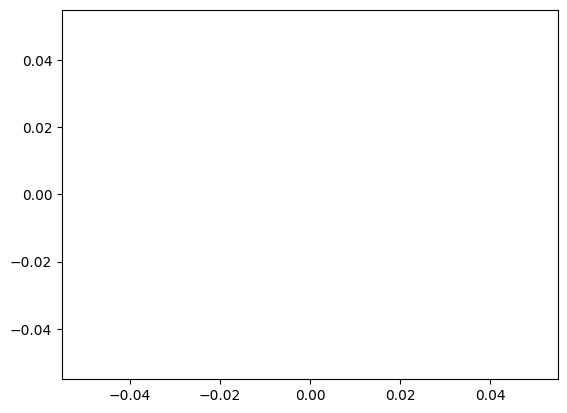

In [9]:
plt.figure()
plt.plot(time,np.std(delta,axis=1))
plt.show()

In [10]:
len(delta)

100

(array([   0.,    0.,    0.,    0.,    0., 1000.,    0.,    0.,    0.,
           0.]),
 array([-0.5, -0.4, -0.3, -0.2, -0.1,  0. ,  0.1,  0.2,  0.3,  0.4,  0.5]),
 <BarContainer object of 10 artists>)

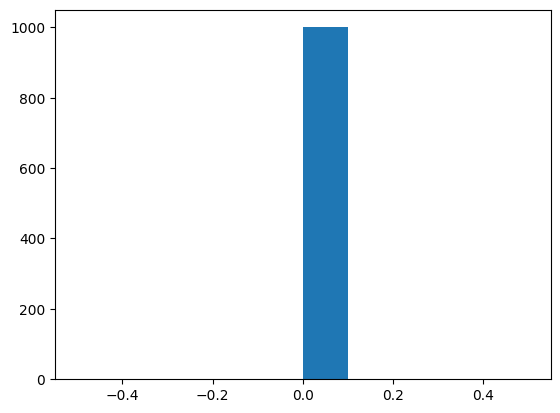

In [11]:
plt.hist(delta[71])

In [12]:
import numpy as np
import scipy.optimize as opt
def gaussian(x, A, mu, sigma):
        return A * np.exp(-((x - mu) ** 2) / (2 * sigma ** 2))

data=particles.delta[particles.state>0]
bins = int(np.sqrt(len(data)))  
hist, bin_edges = np.histogram(data, bins=bins, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  

A_init = max(hist)  
mu_init = np.mean(data)  
sigma_init = np.std(data)  

p0 = [A_init, mu_init, sigma_init]

params, covariance = opt.curve_fit(gaussian, bin_centers, hist, p0=p0)

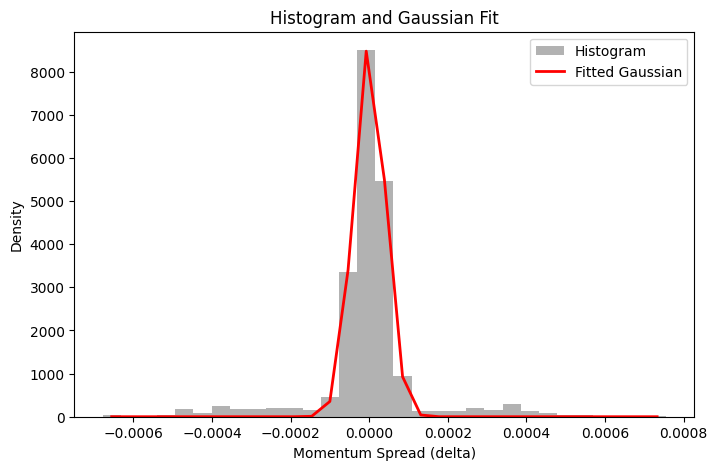

In [13]:
import numpy as np
import scipy.optimize as opt
import matplotlib.pyplot as plt

# Define Gaussian function
def gaussian(x, A, mu, sigma):
    return A * np.exp(-((x - mu) ** 2) / (2 * sigma ** 2))

# Generate sample data for testing (since `particles` is not available)
np.random.seed(42)
data = particles.delta[particles.state > 0]

# Compute histogram
bins = int(np.sqrt(len(data)))  
hist, bin_edges = np.histogram(data, bins=bins, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  

# Initial parameter estimates
A_init = max(hist)  
mu_init = np.mean(data)  
sigma_init = np.std(data)  

p0 = [A_init, mu_init, sigma_init]

# Fit the Gaussian to the histogram
params, covariance = opt.curve_fit(gaussian, bin_centers, hist, p0=p0,maxfev=10000)
A_fit, mu_fit, sigma_fit = params

# Plot histogram and fitted Gaussian
plt.figure(figsize=(8, 5))
plt.hist(data, bins=bins, density=True, alpha=0.6, color='gray', label='Histogram')
plt.plot(bin_centers, gaussian(bin_centers, *params), 'r-', linewidth=2, label='Fitted Gaussian')

# Labels and legend
plt.xlabel('Momentum Spread (delta)')
plt.ylabel('Density')
plt.title('Histogram and Gaussian Fit')
plt.legend()
plt.show()


In [14]:
bin_edges

array([-6.78055573e-04, -6.31812372e-04, -5.85569172e-04, -5.39325972e-04,
       -4.93082772e-04, -4.46839571e-04, -4.00596371e-04, -3.54353171e-04,
       -3.08109970e-04, -2.61866770e-04, -2.15623570e-04, -1.69380369e-04,
       -1.23137169e-04, -7.68939686e-05, -3.06507683e-05,  1.55924320e-05,
        6.18356323e-05,  1.08078833e-04,  1.54322033e-04,  2.00565233e-04,
        2.46808434e-04,  2.93051634e-04,  3.39294834e-04,  3.85538035e-04,
        4.31781235e-04,  4.78024435e-04,  5.24267636e-04,  5.70510836e-04,
        6.16754036e-04,  6.62997237e-04,  7.09240437e-04,  7.55483637e-04])

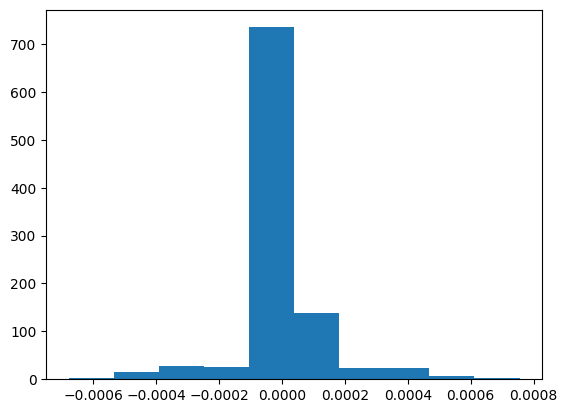

In [15]:
plt.figure()
plt.hist(particles.delta)
plt.show()

In [16]:
print("beta_x:", beta_x)
print("beta_y:", beta_y)
print("alpha_x:", alpha_x)
print("alpha_y:", alpha_y)
print("gamma_x:", gamma_x)
print("gamma_y:", gamma_y)
print("Dx:", Dx)
print("Dpx:", Dpx)
print("Dy:", Dy)
print("Dpy:", Dpy)


beta_x: 54.46611023891781
beta_y: 44.39557646380093
alpha_x: -1.5456070795347345
alpha_y: 1.3225757163115908
gamma_x: 0.06222043232417969
gamma_y: 0.061925235448147715
Dx: 2.3261652157336967
Dpx: 0.09359130580265473
Dy: -0.0
Dpy: -0.0


Transverse emittance

In [17]:
time

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

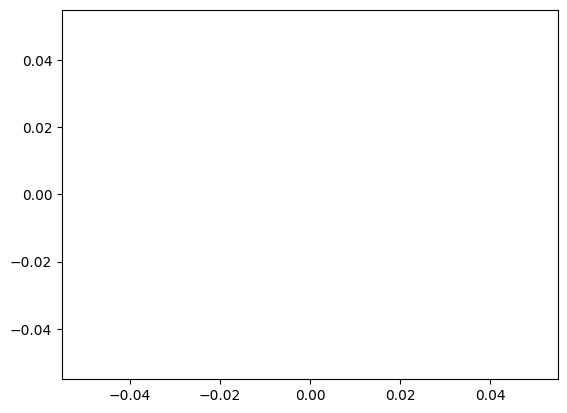

In [18]:
plt.plot(time,emittance_x_twiss)

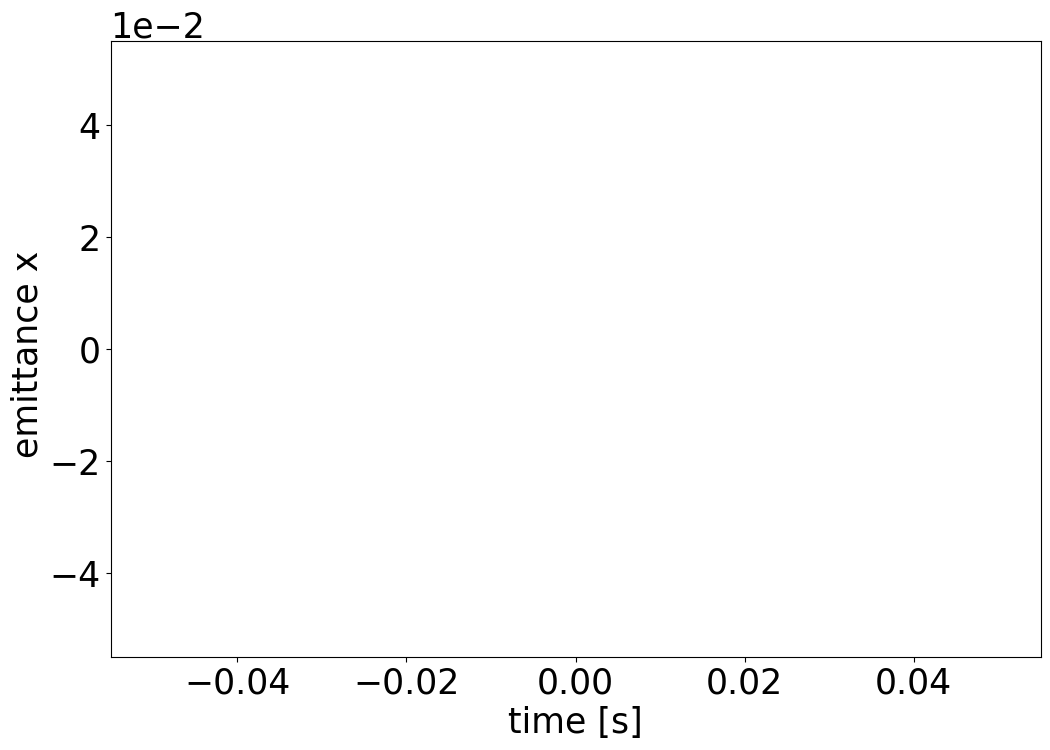

In [19]:
plt.figure(figsize=(12, 8))
plt.rcParams.update({'font.size': 25})
plt.plot(time,emittance_x_twiss)
plt.xlabel('time [s]')
plt.ylabel('emittance x ')
ax = plt.gca()
# Removing the offset from the y-axis tick labels
ax.yaxis.get_major_formatter().set_useOffset(False)
# plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.show()

In [20]:
len(particles.x)

1000

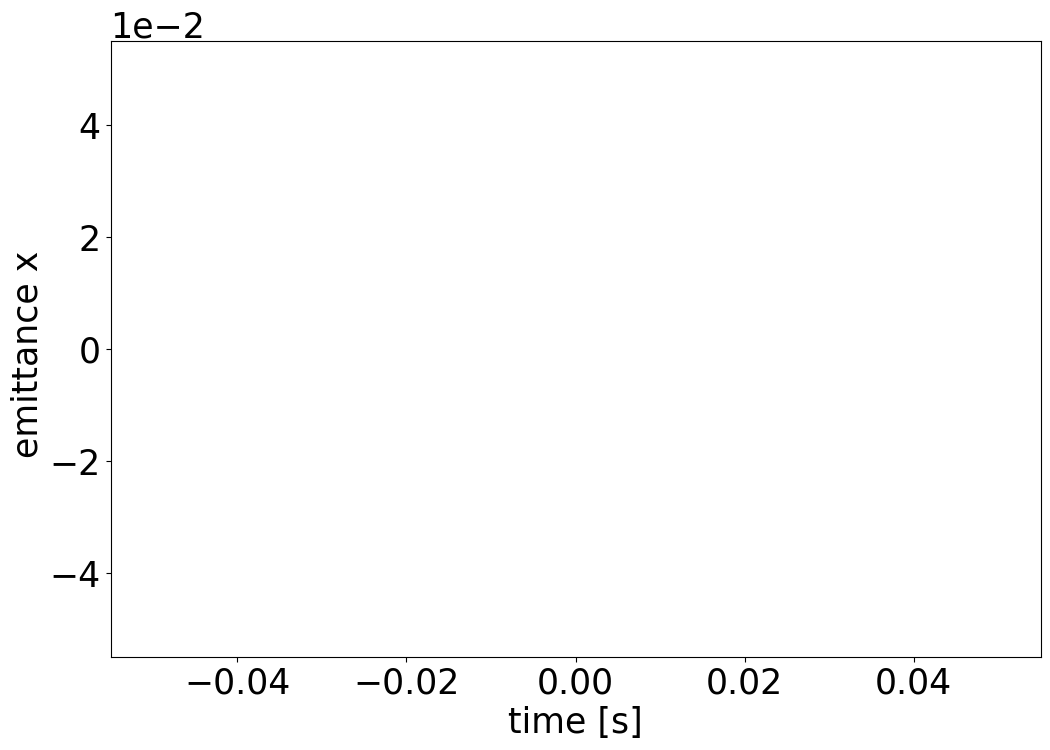

In [21]:
plt.figure(figsize=(12, 8))
plt.rcParams.update({'font.size': 25})
plt.plot(time,emittance_x_twiss)
plt.xlabel('time [s]')
plt.ylabel('emittance x ')
ax = plt.gca()
# Removing the offset from the y-axis tick labels
ax.yaxis.get_major_formatter().set_useOffset(False)
# plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.show()

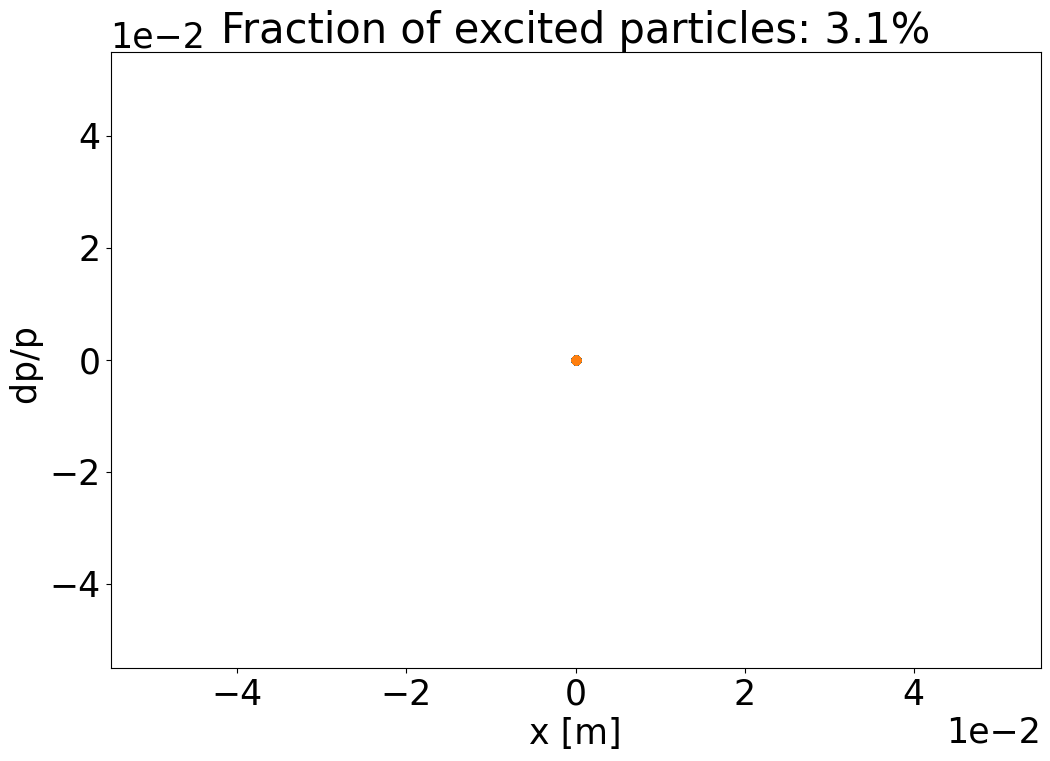

In [22]:
excited=particles.state==2
fraction_excitation = sum(excited)/len(excited)


plt.figure(figsize=(12, 8))
plt.rcParams.update({'font.size': 25})
plt.title(f'Fraction of excited particles: {fraction_excitation*100:.3}%')
plt.scatter(x[-1,:],delta[-1,:])
plt.scatter(x[-1,:][excited],delta[-1,:][excited])
plt.xlabel('x [m]')
plt.ylabel('dp/p ')
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.show()


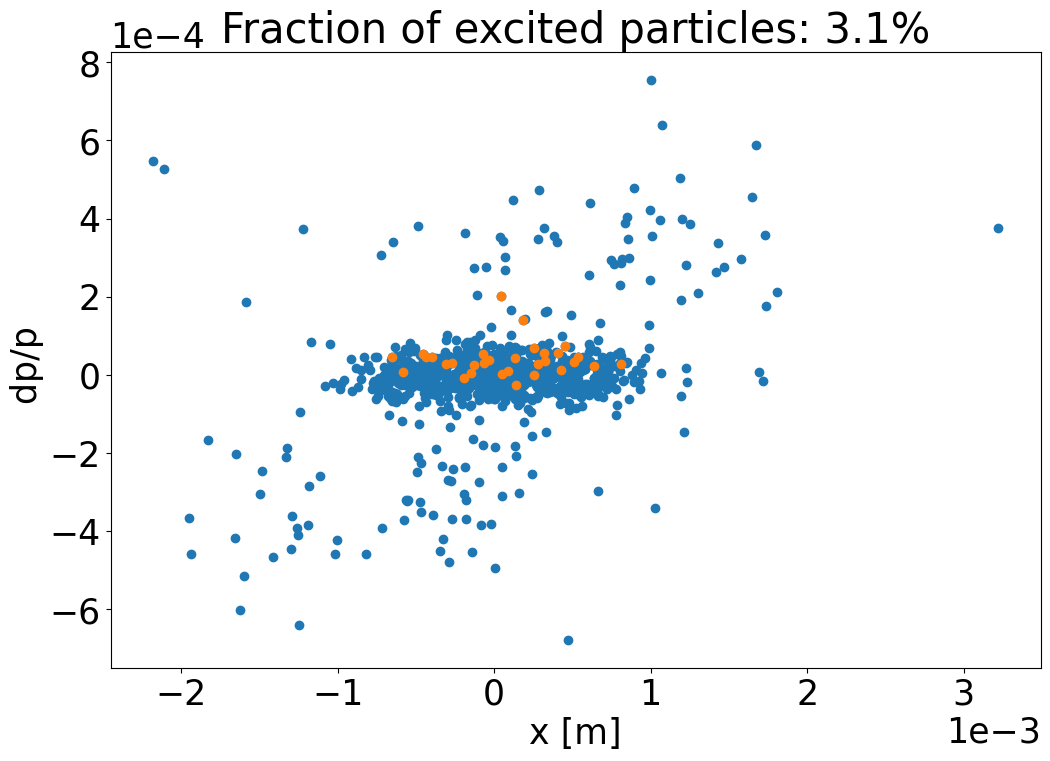

In [23]:
plt.figure(figsize=(12, 8))
plt.rcParams.update({'font.size': 25})
plt.title(f'Fraction of excited particles: {fraction_excitation*100:.3}%')
plt.scatter(particles.x,particles.delta)
plt.scatter(particles.x[excited],particles.delta[excited])
plt.xlabel('x [m]')
plt.ylabel('dp/p ')
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.show()

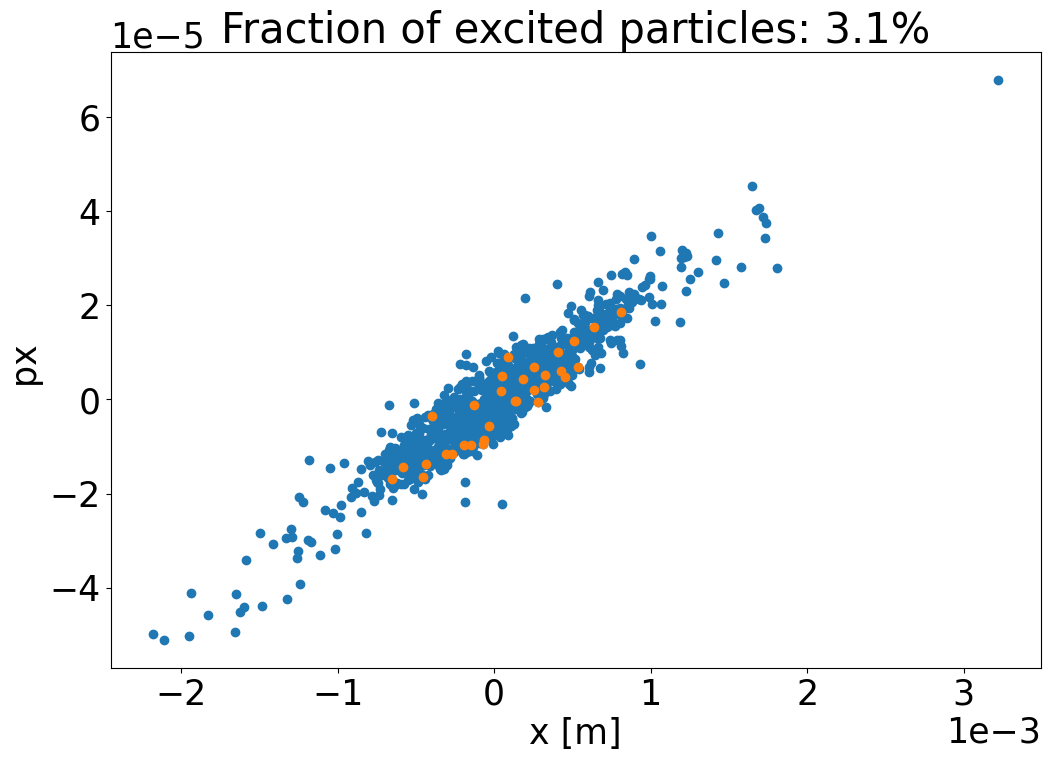

In [24]:
plt.figure(figsize=(12, 8))
plt.rcParams.update({'font.size': 25})
plt.title(f'Fraction of excited particles: {fraction_excitation*100:.3}%')
plt.scatter(particles.x,particles.px)
plt.scatter(particles.x[excited],particles.px[excited])
plt.xlabel('x [m]')
plt.ylabel('px ')
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.show()

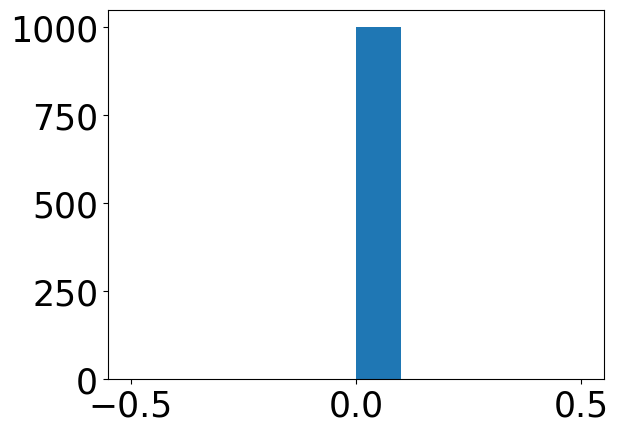

In [25]:
plt.figure()
plt.hist(delta[-1])
plt.show()

/home/pkruyt/miniforge3/envs/xsuite_coolers/lib/python3.13/site-packages/scipy/stats/_distn_infrastructure.py:2046: RuntimeWarning: divide by zero encountered in divide
  x = np.asarray((x - loc)/scale, dtype=dtyp)


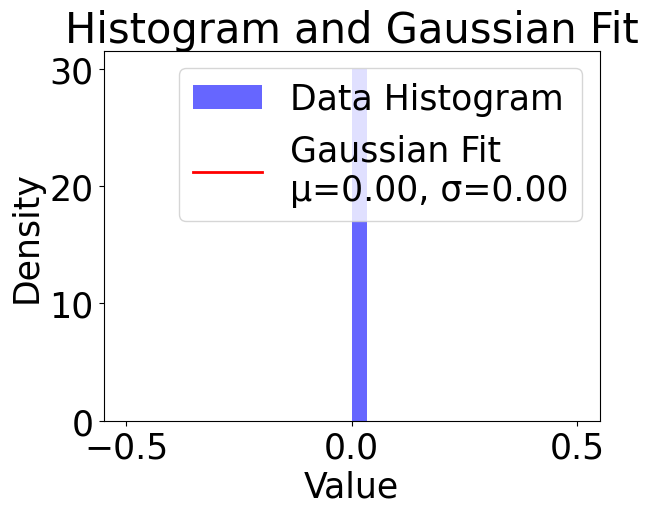

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Assuming delta is a NumPy array or list, take the last row or entry
data = delta[-1]  

# Fit a Gaussian (normal distribution)
mu, sigma = norm.fit(data)  # Estimate mean and standard deviation

# Create histogram
plt.figure()
plt.hist(data, bins=30, density=True, alpha=0.6, color='b', label="Data Histogram")

# Create a range of values for the fitted curve
xmin, xmax = plt.xlim()  # Get x-axis limits
x = np.linspace(xmin, xmax, 100)

# Plot the fitted Gaussian
p = norm.pdf(x, mu, sigma)
plt.plot(x, p, 'r-', linewidth=2, label=f"Gaussian Fit\nμ={mu:.2f}, σ={sigma:.2f}")

# Labels and legend
plt.xlabel("Value")
plt.ylabel("Density")
plt.title("Histogram and Gaussian Fit")
plt.legend()
plt.show()


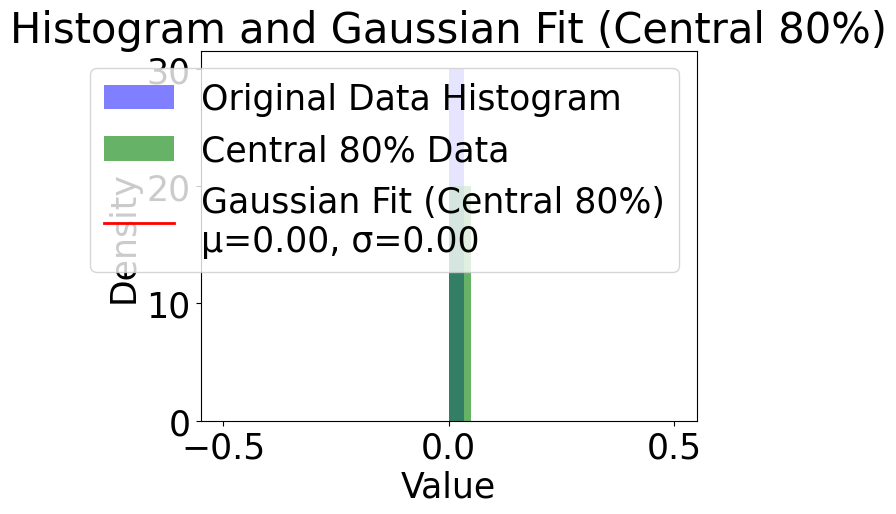

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Extract the last dataset from delta
data = np.array(delta[-1])  # Ensure it's a NumPy array

# Compute 10th and 90th percentiles
p10, p90 = np.percentile(data, [10, 90])

# Select only values within the central 80% range
filtered_data = data[(data >= p10) & (data <= p90)]

# Fit a Gaussian to the filtered data
mu, sigma = norm.fit(filtered_data)

# Plot original histogram
plt.figure()
plt.hist(data, bins=30, density=True, alpha=0.5, color='b', label="Original Data Histogram")

# Plot histogram of the central 80% data
plt.hist(filtered_data, bins=20, density=True, alpha=0.6, color='g', label="Central 80% Data")

# Create a range of values for the fitted curve
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)

# Plot the fitted Gaussian (based on the central 80%)
p = norm.pdf(x, mu, sigma)
plt.plot(x, p, 'r-', linewidth=2, label=f"Gaussian Fit (Central 80%)\nμ={mu:.2f}, σ={sigma:.2f}")

# Labels and legend
plt.xlabel("Value")
plt.ylabel("Density")
plt.title("Histogram and Gaussian Fit (Central 80%)")
plt.legend()
plt.show()


In [28]:
sigma

np.float64(0.0)

In [29]:
state[-1]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,